# Creating an Reservoir Artificial Metabolic (AMN) Reservoir with **Aida & Ying (2025)** experimental medium


This notebook demonstrates the pipeline for using AMNs with a large-scale dataset of *Escherichia coli* growth under well-defined laboratory conditions (Aida & Ying, 2025). The purpose if to use this dataset for training Artificial Metabolic Networks (Faure et al., 2023) that can learn to map `media concentration` $\rightarrow$ `uptake flux`

---

Aida, H., & Ying, B. (2025). Population Dynamics of Escherichia coli Growing under Chemically Defined Media. Scientific Data, 12(1), 984. https://doi.org/10.1038/s41597-025-05356-3

## Set up environment

In [1]:
# Automatic module reloading
%load_ext autoreload
%autoreload 2

# Imports
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score

# Working directory
DIRECTORY = './'
print(os.listdir(DIRECTORY)) # prints the files


['.git', 'Results', 'Duplicate_Model.ipynb', '.gitignore', 'Figures.ipynb', 'experiments', 'Build_Model_ANN_Dense.ipynb', 'Build_Dataset.ipynb', 'Figures', 'Result', 'Tutorial.ipynb', 'Build_Model_MM.ipynb', 'pyproject.toml', 'Reservoir', 'environment_amn.yml', 'Tutorial_Aida.ipynb', 'Build_Experimental.ipynb', 'Dataset_model', 'uv.lock', 'Build_Dataset_KO.ipynb', 'Build_Model_RC.ipynb', 'environment_amn_light.yml', 'Library', 'Tutorial_Cmed.ipynb', 'README.md', 'Build_Model_AMN.ipynb', 'Dataset_experimental', 'Build_Model_AMN_KO.ipynb', '.venv', 'LICENSE', 'Dataset_input']


In [2]:
# filter out INFO, WARNING, and ERROR logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import tensorflow as tf
tf.get_logger().setLevel('ERROR')  # suppress Python-level TF warnings

# Check GPU availability
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPUs: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow Version: 2.15.1
GPUs: 1


## Step 1: Prepare Genome-Scale Model

A requirement for neural computations with metabolic networks using AMNs is the positivity of all fluxes. This means duplicating the reversible reactions in the Genome-Scale Model (GEM) used, making it irreversible.

The following steps transform an SBML model into an *AMN-compatible*  model where: **all exchange reactions are possible in both ways, and reversible internal reactions are duplicated for each way**.

In [188]:
# Import the module
from Library.Duplicate_Model import *

In [189]:
# iML1515 model
model_path = "Dataset_input/iML1515.xml"
url = "http://bigg.ucsd.edu/static/models/iML1515.xml"
response = requests.get(url)
open(model_path, "wb").write(response.content)
model = cobra.io.read_sbml_model(model_path)

In [190]:
# Boundary reactions
# reactions that introduce or remove matter in the system (inflows, outflows)
boundary_rxns = model.boundary
print(f"Total number of boundary reactions: {len(boundary_rxns)}")
    
# Medium reactions
# reactions in .boundary that are reversible
medium_rxns = model.medium
print(f"\nTotal number of medium reactions: {len(medium_rxns)}")
print(f"All medium reactions: {medium_rxns}")


Total number of boundary reactions: 337

Total number of medium reactions: 24
All medium reactions: {'EX_pi_e': 1000.0, 'EX_co2_e': 1000.0, 'EX_fe3_e': 1000.0, 'EX_h_e': 1000.0, 'EX_mn2_e': 1000.0, 'EX_fe2_e': 1000.0, 'EX_glc__D_e': 10.0, 'EX_zn2_e': 1000.0, 'EX_mg2_e': 1000.0, 'EX_ca2_e': 1000.0, 'EX_ni2_e': 1000.0, 'EX_cu2_e': 1000.0, 'EX_sel_e': 1000.0, 'EX_cobalt2_e': 1000.0, 'EX_h2o_e': 1000.0, 'EX_mobd_e': 1000.0, 'EX_so4_e': 1000.0, 'EX_nh4_e': 1000.0, 'EX_k_e': 1000.0, 'EX_na1_e': 1000.0, 'EX_cl_e': 1000.0, 'EX_o2_e': 1000.0, 'EX_tungs_e': 1000.0, 'EX_slnt_e': 1000.0}


In [191]:
io_dict = {"_i": [(None, "e"), (None, "c"), ("e","p"), ("p", "c"), ("e", "c"), ("c", "m"), ("p", "m")],
           "_o": [("c", None), ("e", None), ("p", "e"), ("c", "p"), ("c", "e"), ("m", "c"), ("m", "p")]}

unsignificant_mols = ["h_p", "h_c", "pi_c", "pi_p", "adp_c", "h2o_c", "atp_c"]

# Dictionary counting the reactions in reversible, forward, backward, open 
reac_id_to_io_count_and_way = screen_out_in(model, io_dict, unsignificant_mols)

# Structure of the screening dictionary
print()
print(reac_id_to_io_count_and_way)

{'r': 663, 'f': 2047, 'b': 0, 'o': 2}

{'NDPK5': [{'_i': 0, '_o': 0}, 'r'], 'SHK3Dr': [{'_i': 0, '_o': 0}, 'r'], 'NDPK6': [{'_i': 0, '_o': 0}, 'r'], 'NDPK8': [{'_i': 0, '_o': 0}, 'r'], 'DHORTS': [{'_i': 0, '_o': 0}, 'r'], 'PYNP2r': [{'_i': 0, '_o': 0}, 'r'], 'ICDHyr': [{'_i': 0, '_o': 0}, 'r'], 'DURIPP': [{'_i': 0, '_o': 0}, 'r'], 'ACALD': [{'_i': 0, '_o': 0}, 'r'], 'MAN6PI': [{'_i': 0, '_o': 0}, 'r'], 'TRPAS2': [{'_i': 0, '_o': 0}, 'r'], 'ALAR': [{'_i': 0, '_o': 0}, 'r'], 'ALATA_L': [{'_i': 0, '_o': 0}, 'r'], 'PPM': [{'_i': 0, '_o': 0}, 'r'], 'ASPTA': [{'_i': 0, '_o': 0}, 'r'], 'EX_pi_e': [{'_i': 0, '_o': 1}, 'r'], 'EX_co2_e': [{'_i': 0, '_o': 1}, 'r'], 'A5PISO': [{'_i': 0, '_o': 0}, 'r'], 'EX_met__L_e': [{'_i': 0, '_o': 1}, 'f'], 'GTHOr': [{'_i': 0, '_o': 0}, 'r'], 'ILETA': [{'_i': 0, '_o': 0}, 'r'], 'EX_metsox_S__L_e': [{'_i': 0, '_o': 1}, 'f'], 'VALTA': [{'_i': 0, '_o': 0}, 'r'], 'IPPMIb': [{'_i': 0, '_o': 0}, 'r'], 'ORPT': [{'_i': 0, '_o': 0}, 'r'], 'PSCVT': [{'_i': 0, '_o': 0}, '

In [192]:
# Use the dictionary to generate the AMN-compatible model
new_model = duplicate_model(model, reac_id_to_io_count_and_way)

The default model had 2712 reactions and the duplicated-reactions model has 3682 reactions.


In [193]:
# all non-default medium exchange reactions with UB=0 are set to 1e-300
# so they still appear in the medium object.
default_med = model.medium
new_med = new_model.medium
correct_med =  correct_duplicated_med(default_med, new_med)
new_model.medium = correct_med

print(f"Default medium: {len(default_med)} compounds")
print(f"\nCorrected medium: {len(correct_med)} compounds")

Default medium: 24 compounds

Corrected medium: 331 compounds


In [194]:
# Rebuild indices and pointers in the model if necessary
new_model.repair() 

In [195]:
print("Original model's location: " + model_path)
new_name = model_path[:-4] + "_duplicated" + model_path[-4:]

cobra.io.write_sbml_model(new_model, new_name)
print("Duplicated model's location: " + new_name)

Original model's location: Dataset_input/iML1515.xml
Duplicated model's location: Dataset_input/iML1515_duplicated.xml


## Step 2. Aida & Ying Dataset Pre-processing
#### 2.1. Match the Aida & Ying Compounds to iML1515 reactions

In [196]:
# TO DO: Add the aida script process

# Here, use medium_rxns to filter the aida dataset (so we use the vars in the notebook)

#### 2.2. Generate parameter file for `FBA-simulated` training set

An `FBA-simulated` dataset will be generated for training the AMN Reservoir. The reservoir learns the stoichiometric and bound constraints of the GEM from diverse FBA solutions. Thus, the training dataset should:

1. Cover diverse flux patterns - coming from different carbon sources
2. All produce growth > 0 - no infeasible conditions

#### Parameters for random generation

A file with parameters for random generation for the `FBA-simulated` dataset is needed. It's a csv specifying:

- `level`: Number of discrete levels each medium flux can take.
    - `level` <= 1: Minimum medium (always on at a fixed value).
    - `level` > 1: Variable medium (can be turned on/off with multiple levels).

- `max_level`: Maximum value each medium flux can take. Used to compute the actual flux value when a variable medium is turned on.

- `ratio_drawing`: Ratio/probability of variable medium fluxes being turned on during random generation. Not used when `max_level` is provided

We will be using the parameter file from Faure et. al (2023). 

In [197]:
# Load Aida & Yin dataset (already processed to match model's reactions)
aida_path = DIRECTORY + 'Dataset_input/aidaying_media_growth_amns.csv'
aida_df = pd.read_csv(aida_path)

# Compounds in the Aida & Ying dataset
print(f"Aida & Ying DataFrame shape: {aida_df.shape}")
print(f"Columns: {aida_df.columns.tolist()}")

Aida & Ying DataFrame shape: (924, 38)
Columns: ['EX_glc__D_e_i', 'EX_ala__L_e_i', 'EX_arg__L_e_i', 'EX_asn__L_e_i', 'EX_asp__L_e_i', 'EX_glu__L_e_i', 'EX_gln__L_e_i', 'EX_gly_e_i', 'EX_his__L_e_i', 'EX_ile__L_e_i', 'EX_leu__L_e_i', 'EX_lys__L_e_i', 'EX_met__L_e_i', 'EX_phe__L_e_i', 'EX_pro__L_e_i', 'EX_ser__L_e_i', 'EX_thr__L_e_i', 'EX_trp__L_e_i', 'EX_tyr__L_e_i', 'EX_val__L_e_i', 'EX_thm_e_i', 'EX_pydxn_e_i', 'EX_cys__L_e_i', 'EX_cl_e_i', 'EX_nh4_e_i', 'EX_so4_e_i', 'EX_pi_e_i', 'EX_k_e_i', 'EX_na1_e_i', 'EX_mg2_e_i', 'EX_ca2_e_i', 'EX_fe2_e_i', 'EX_zn2_e_i', 'EX_cu2_e_i', 'EX_mobd_e_i', 'EX_cit_e_i', 'EX_tsul_e_i', 'GR_AVG']


In [198]:
# EDA on aida_df
global_min = aida_df.min().min()
global_max = aida_df.max().max()
print(f"Minimum across all columns: {global_min}")
print(f"Maximum across all columns: {global_max}")


Minimum across all columns: 0.0
Maximum across all columns: 343.0


In [199]:
# Load parameter file from Faure et. al 
faure_path = DIRECTORY + 'Dataset_input/iML1515.csv'
faure_df = pd.read_csv(faure_path)

# Compounds in the Faure et. al parameter file
print(f"Faure DataFrame shape: {faure_df.shape}")
print(f"Columns: {faure_df.columns.tolist()}")
faure_df.head(3)

Faure DataFrame shape: (4, 39)
Columns: ['name', 'EX_pi_e_i', 'EX_co2_e_i', 'EX_fe3_e_i', 'EX_h_e_i', 'EX_mn2_e_i', 'EX_fe2_e_i', 'EX_zn2_e_i', 'EX_mg2_e_i', 'EX_ca2_e_i', 'EX_ni2_e_i', 'EX_cu2_e_i', 'EX_sel_e_i', 'EX_cobalt2_e_i', 'EX_h2o_e_i', 'EX_mobd_e_i', 'EX_so4_e_i', 'EX_nh4_e_i', 'EX_k_e_i', 'EX_na1_e_i', 'EX_cl_e_i', 'EX_o2_e_i', 'EX_tungs_e_i', 'EX_slnt_e_i', 'EX_glyc_e_i', 'EX_ala__L_e_i', 'EX_pro__L_e_i', 'EX_thr__L_e_i', 'EX_gly_e_i', 'EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i']


,name,EX_pi_e_i,EX_co2_e_i,EX_fe3_e_i,EX_h_e_i,EX_mn2_e_i,EX_fe2_e_i,EX_zn2_e_i,EX_mg2_e_i,EX_ca2_e_i,...,EX_rib__D_e_i,EX_malt_e_i,EX_melib_e_i,EX_tre_e_i,EX_fru_e_i,EX_gal_e_i,EX_ac_e_i,EX_lac__D_e_i,EX_succ_e_i,EX_pyr_e_i
0,level,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1,max_value,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,...,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2
2,ratio_drawing,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [200]:
# Store column names (excluding non-compounds)
faure_cols = faure_df.columns.drop('name')
aida_cols = aida_df.columns.drop('GR_AVG')

print(f"Faure compounds: {len(faure_cols)}")
print(f"Aida & Ying compounds: {len(aida_cols)}")

Faure compounds: 38
Aida & Ying compounds: 37


In [201]:
# Check common compounds
common_compounds = set(faure_cols) & set(aida_cols)
print(f"Common compounds: {len(common_compounds)}")
print(f"Common compounds: {common_compounds}")

# Check Aida only
aida_only = set(aida_cols) - set(faure_cols)
print(f"\nAida & Ying only compounds: {len(aida_only)}")
print(f"Aida & Ying only compounds: {aida_only}")

# Check Faure only
faure_only = set(faure_cols) - set(aida_cols)
print(f"\nFaure only compounds: {len(faure_only)}")
print(f"Faure only compounds: {faure_only}")

Common compounds: 16
Common compounds: {'EX_thr__L_e_i', 'EX_mobd_e_i', 'EX_gly_e_i', 'EX_so4_e_i', 'EX_ala__L_e_i', 'EX_ca2_e_i', 'EX_cu2_e_i', 'EX_nh4_e_i', 'EX_mg2_e_i', 'EX_na1_e_i', 'EX_k_e_i', 'EX_pi_e_i', 'EX_fe2_e_i', 'EX_zn2_e_i', 'EX_pro__L_e_i', 'EX_cl_e_i'}

Aida & Ying only compounds: 21
Aida & Ying only compounds: {'EX_thm_e_i', 'EX_cit_e_i', 'EX_gln__L_e_i', 'EX_ser__L_e_i', 'EX_glu__L_e_i', 'EX_trp__L_e_i', 'EX_val__L_e_i', 'EX_met__L_e_i', 'EX_tsul_e_i', 'EX_phe__L_e_i', 'EX_pydxn_e_i', 'EX_arg__L_e_i', 'EX_glc__D_e_i', 'EX_cys__L_e_i', 'EX_lys__L_e_i', 'EX_asp__L_e_i', 'EX_asn__L_e_i', 'EX_tyr__L_e_i', 'EX_his__L_e_i', 'EX_ile__L_e_i', 'EX_leu__L_e_i'}

Faure only compounds: 22
Faure only compounds: {'EX_lac__D_e_i', 'EX_fe3_e_i', 'EX_glyc_e_i', 'EX_o2_e_i', 'EX_mn2_e_i', 'EX_h_e_i', 'EX_rib__D_e_i', 'EX_ac_e_i', 'EX_succ_e_i', 'EX_tungs_e_i', 'EX_malt_e_i', 'EX_fru_e_i', 'EX_slnt_e_i', 'EX_co2_e_i', 'EX_tre_e_i', 'EX_sel_e_i', 'EX_cobalt2_e_i', 'EX_melib_e_i', 'EX_ni

We need to supplement the Faure parameter file with the compounds from the Aida & Ying dataset. This way, the reservoir will have seen flux patterns involving the experimental compounds.

We can classify the Aida & Ying only compounds in two categories:
- 2 Variable carbon sources: `EX_glc__D_e_i` and `EX_cit_e_i`
   - These can be ON/OFF
   - Assign `level`: 100, `max_value`: 2.2
- 19 Vitamins and aminoacids: `EX_thm_e_i`, `EX_arg__L_e_i`, ...
   - These are essential for growth and should always be ON
   - Assign `level`: 1, `max_value`: 2.2

The `max_value`: 2.2 is set to match Faure's original parameter file. Since the reservoir just needs to learn diverse feasible FBA patterns (not exact concentrations), keeping this arbitrary max values is valid.

In [202]:
# Add the Aida & Ying compounds to the Faure dataset

new_data = {}

for compound in aida_only:
    if compound in ['EX_glc__D_e_i', 'EX_cit_e_i']:
        level_val = 100
    else:
        level_val = 1
    # [name, level, max_value, ratio_drawing]
    new_data[compound] = [level_val, 0.5, np.nan, np.nan]


print(f"Original Faure shape: {faure_df.shape}")

# Add the new columns to the Faure dataset
if new_data:
    new_cols_df = pd.DataFrame(new_data, index=faure_df.index)
    faure_df = pd.concat([faure_df, new_cols_df], axis=1)

print(f"Faure shape with Aida & Ying compounds: {faure_df.shape}")
faure_df.head(3)

Original Faure shape: (4, 39)
Faure shape with Aida & Ying compounds: (4, 60)


,name,EX_pi_e_i,EX_co2_e_i,EX_fe3_e_i,EX_h_e_i,EX_mn2_e_i,EX_fe2_e_i,EX_zn2_e_i,EX_mg2_e_i,EX_ca2_e_i,...,EX_arg__L_e_i,EX_glc__D_e_i,EX_cys__L_e_i,EX_lys__L_e_i,EX_asp__L_e_i,EX_asn__L_e_i,EX_tyr__L_e_i,EX_his__L_e_i,EX_ile__L_e_i,EX_leu__L_e_i
0,level,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,100.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,max_value,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
2,ratio_drawing,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [203]:
# Export
faure_df.to_csv(DIRECTORY + 'Dataset_input/aidaying_parameters.csv', index=False)

#### 2.3. Padding the Aida & Ying dataset

Because the AMN reservoir training data must match the experimental data (have the same type and number of `compounds`), the Aida & Ying dataset must be padded with the compounds in the Faure dataset. 

There's 2 categories of compounds in this padding:
- **Compounds present but not measured**
   - Reflect environmental conditions (`EX_o2_e_i`, `EX_co2_e_i`, ...)
   - These will be constant across all rows
   - Values (in mM) were selected from standard *E. coli* defined media concentrations
      - These could be adjusted
 - **Compounds genuinely absent**     
   - Not essential/environmental (`EX_glyc_e_i`, `EX_malt_e_i`, ...)
   - These will be 0 across all rows


*Note on H₂O:*
- A common value for water concentration in media is 55,000 mM, but this will be is an outlier that could dominate the feature space
- To prevent distorting the input distribution, we assign 500 for H₂O

In [204]:
# Compounds present but not measured
unmeasured_compounds = {
    'EX_o2_e_i': 0.21,
    'EX_co2_e_i': 0.013,
    'EX_h_e_i': 0.0001,
    'EX_h2o_e_i': 500.0,
    'EX_fe3_e_i': 0.0005,
    'EX_mn2_e_i': 0.0001,
    'EX_ni2_e_i': 0.0001,
    'EX_sel_e_i': 0.0001,
    'EX_cobalt2_e_i': 0.0001,
    'EX_tungs_e_i': 0.0001,
    'EX_slnt_e_i': 0.0001
}

# Compounds genuinely absent
absent_compounds = {
    'EX_glyc_e_i': 0.0,
    'EX_rib__D_e_i': 0.0,
    'EX_malt_e_i': 0.0,
    'EX_melib_e_i': 0.0,
    'EX_tre_e_i': 0.0,
    'EX_fru_e_i': 0.0,
    'EX_gal_e_i': 0.0,
    'EX_ac_e_i': 0.0,
    'EX_lac__D_e_i': 0.0,
    'EX_succ_e_i': 0.0,
    'EX_pyr_e_i': 0.0
}

compounds_to_add = {**unmeasured_compounds, **absent_compounds}

In [205]:
# Pad the Aida & Ying dataset with the missing compounds from the Faure dataset

print(f"Original Aida shape: {aida_df.shape}")

# Temporarily remove GR_AVG to preserve order
gr_avg_col = aida_df.pop('GR_AVG')

# Create a DataFrame with the new columns
new_data = {
    col: val 
    for col, val in compounds_to_add.items()
}
new_cols_df = pd.DataFrame(new_data, index=aida_df.index)

# Concatenate
aida_df = pd.concat([aida_df, new_cols_df], axis=1)

# Add GR_AVG back as last column
aida_df['GR_AVG'] = gr_avg_col

print(f"New Aida shape: {aida_df.shape}")

Original Aida shape: (924, 38)
New Aida shape: (924, 60)


In [206]:
# Export
aida_df.to_csv(DIRECTORY + 'Dataset_input/aidaying_media_growth_amns_padded.csv', index=False)

## Step 3. Generate `FBA-simulated` training set for Reservoir AMN

An `FBA-simulated` dataset will be generated for the AMN Reservoir with experimental data.
This generation relies on using the Aida & Ying Dataset, a csv where `rows = conditions` and `cols = exchanges`+`growth_value`.

We use the padded version from the previous step.

### 3.1 Retrieve compounds in Aida & Ying padded

In [207]:
from Library.Build_Dataset import *

# Set parameters
seed = 10
np.random.seed(seed=seed)  # seed for random number generator
cobraname =  'iML1515_duplicated' # name of the model 
mediumbound = 'UB' # Exact bound (EB) or upper bound (UB)
expname = 'aidaying_media_growth_amns_padded' # name of the experimental dataset for constraints
size, size_i  = 924, 50 # (# of exp conditions, training set size per condition)
reduce = False # Set at True if you want to reduce the model
mediumsize = 59 # number of medium compounds
verbose = True # prints

# Get X from experimental dataset
cobrafile = DIRECTORY+'Dataset_input/'+cobraname # .xml
expfile  = DIRECTORY+'Dataset_input/'+expname # .csv

# Generate a parameter object with the experimental data
parameter = TrainingSet(cobraname=cobrafile, 
                        mediumname=expfile, 
                        mediumbound=mediumbound, 
                        mediumsize=mediumsize, 
                        method='EXP',
                        verbose=verbose)


medium: ['EX_glc__D_e_i', 'EX_ala__L_e_i', 'EX_arg__L_e_i', 'EX_asn__L_e_i', 'EX_asp__L_e_i', 'EX_glu__L_e_i', 'EX_gln__L_e_i', 'EX_gly_e_i', 'EX_his__L_e_i', 'EX_ile__L_e_i', 'EX_leu__L_e_i', 'EX_lys__L_e_i', 'EX_met__L_e_i', 'EX_phe__L_e_i', 'EX_pro__L_e_i', 'EX_ser__L_e_i', 'EX_thr__L_e_i', 'EX_trp__L_e_i', 'EX_tyr__L_e_i', 'EX_val__L_e_i', 'EX_thm_e_i', 'EX_pydxn_e_i', 'EX_cys__L_e_i', 'EX_cl_e_i', 'EX_nh4_e_i', 'EX_so4_e_i', 'EX_pi_e_i', 'EX_k_e_i', 'EX_na1_e_i', 'EX_mg2_e_i', 'EX_ca2_e_i', 'EX_fe2_e_i', 'EX_zn2_e_i', 'EX_cu2_e_i', 'EX_mobd_e_i', 'EX_cit_e_i', 'EX_tsul_e_i', 'EX_o2_e_i', 'EX_co2_e_i', 'EX_h_e_i', 'EX_h2o_e_i', 'EX_fe3_e_i', 'EX_mn2_e_i', 'EX_ni2_e_i', 'EX_sel_e_i', 'EX_cobalt2_e_i', 'EX_tungs_e_i', 'EX_slnt_e_i', 'EX_glyc_e_i', 'EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i']
levmed: []
valmed: []
ratmed: 0
objective:  ['BIOMASS_Ec_iML1515_core_75p37M']
measurements

In [208]:
# Store the medium data 
# (X matrix, where rows are conditions and columns are compounds)
X = parameter.X.copy()
print("X shape:")
print(X.shape)
print("X:")
print(f"{X}\n")

# Store the growth data 
# (Y vector, where each element is the growth rate of the condition)
Y = parameter.Y.copy()
print("Y shape:")
print(Y.shape)
print("Y:")
print(f"{Y}")

X shape:
(924, 59)
X:
[[2.000e+00 2.000e-02 2.000e-02 ... 0.000e+00 0.000e+00 0.000e+00]
 [2.000e+00 2.000e-02 2.000e-02 ... 0.000e+00 0.000e+00 0.000e+00]
 [2.000e+00 2.000e-02 2.000e-02 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [4.342e+01 4.800e-01 4.600e-01 ... 0.000e+00 0.000e+00 0.000e+00]
 [4.342e+01 4.800e-01 4.600e-01 ... 0.000e+00 0.000e+00 0.000e+00]
 [4.342e+01 4.800e-01 4.600e-01 ... 0.000e+00 0.000e+00 0.000e+00]]

Y shape:
(924, 1)
Y:
[[0.        ]
 [1.35195701]
 [1.21247769]
 [1.31664145]
 [1.20613912]
 [1.2096604 ]
 [1.18665536]
 [1.2630026 ]
 [1.30251915]
 [1.16141401]
 [1.29121789]
 [1.19038438]
 [1.13983402]
 [0.93687068]
 [1.26857109]
 [1.05723604]
 [0.94498256]
 [1.1675341 ]
 [1.21453758]
 [1.15494106]
 [1.04952889]
 [1.22009679]
 [1.24604945]
 [1.16347754]
 [1.19674906]
 [1.23475186]
 [1.28648177]
 [1.22757426]
 [1.20015331]
 [1.15708897]
 [1.13678278]
 [1.15224194]
 [1.1473662 ]
 [1.07225977]
 [1.20539115]
 [1.12868891]
 [1.11913337]
 [1.06169291]
 [1.0134549 ]
 [

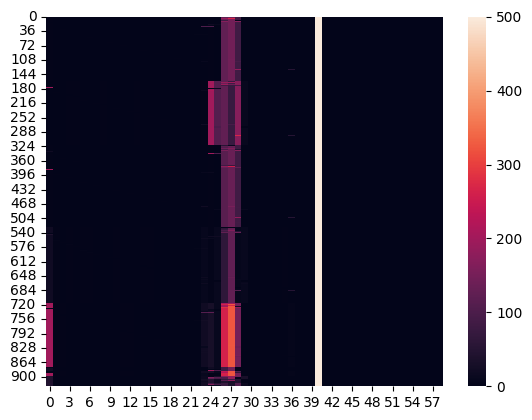

In [209]:
# Heatmap of the medium (conditions, compounds)
sns.heatmap(pd.DataFrame(X))
plt.show()

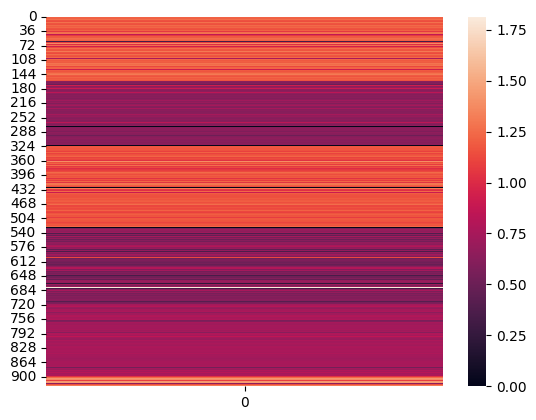

In [210]:
# Heatmap of the growth (conditions)
sns.heatmap(pd.DataFrame(Y))
plt.show()

In [211]:
# Get parameter object for reservoir training set from a medium file
# 'method' is pFBA because this file contains parameters for random generation
mediumname = 'aidaying_parameters'
mediumfile = DIRECTORY+'Dataset_input/'+mediumname #.csv
parameter = TrainingSet(cobraname=cobrafile, 
                        mediumname=mediumfile, 
                        mediumbound=mediumbound, 
                        method='FBA',
                        verbose=verbose)

medium: ['EX_pi_e_i', 'EX_co2_e_i', 'EX_fe3_e_i', 'EX_h_e_i', 'EX_mn2_e_i', 'EX_fe2_e_i', 'EX_zn2_e_i', 'EX_mg2_e_i', 'EX_ca2_e_i', 'EX_ni2_e_i', 'EX_cu2_e_i', 'EX_sel_e_i', 'EX_cobalt2_e_i', 'EX_h2o_e_i', 'EX_mobd_e_i', 'EX_so4_e_i', 'EX_nh4_e_i', 'EX_k_e_i', 'EX_na1_e_i', 'EX_cl_e_i', 'EX_o2_e_i', 'EX_tungs_e_i', 'EX_slnt_e_i', 'EX_glyc_e_i', 'EX_ala__L_e_i', 'EX_pro__L_e_i', 'EX_thr__L_e_i', 'EX_gly_e_i', 'EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_thm_e_i', 'EX_cit_e_i', 'EX_gln__L_e_i', 'EX_ser__L_e_i', 'EX_glu__L_e_i', 'EX_trp__L_e_i', 'EX_val__L_e_i', 'EX_met__L_e_i', 'EX_tsul_e_i', 'EX_phe__L_e_i', 'EX_pydxn_e_i', 'EX_arg__L_e_i', 'EX_glc__D_e_i', 'EX_cys__L_e_i', 'EX_lys__L_e_i', 'EX_asp__L_e_i', 'EX_asn__L_e_i', 'EX_tyr__L_e_i', 'EX_his__L_e_i', 'EX_ile__L_e_i', 'EX_leu__L_e_i']
levmed: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.

In [212]:
# Create varmed: the list of variable compound IDs, based on experimental file (X)
varmed = {}

for i in range(X.shape[0]):
    varmed[i] = []
    for j in range(X.shape[1]):
        if parameter.levmed[j] > 1 and X[i, j] > 0:
            varmed[i].append(parameter.medium[j])

varmed = list(varmed.values())

In [213]:
print(f"varmed len: {len(varmed)}")
print(varmed)

varmed len: 924
[['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_e_i'], ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_e_i'], ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_e_i'], ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_e_i'], ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_e_i'], ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_

##### Explanation of `varmed`
`varmed` is a list that contains the compound IDs present per condition
- `varmed[0] = ['EX_gal_e_i']`: Condition 0 has only galactose as a variable medium
- `varmed[10] = ['EX_melib_e_i', 'EX_gal_e_i']`: Condition 10 has melibiose and galactose

If the compound exists in the medium (`if parameter.levmed[j] > 1`) and is present in the reference medium matrix (`and X[i,j] > 0`) it'll be appended to this list.

### 3.2. Creating the `FBA-simulated` dataset

For each condition (`varmed[i]`) generate `size_i` iterations of FBA-simulated data.

e.g. if `varmed[i] = 110` and `size_i = 100`, the `trainingsize = 11,000` (110x100)

In [214]:
size_i = 10 # samples to generate per condition

# Get a COBRApy-generated training set constrained by varmed
for i in range(X.shape[0]): 
    try:
        print(f"Condition {i}: {varmed[i]}")
        parameter.get(sample_size=size_i, varmed=varmed[i], verbose=True)
    except Exception as e:
        print(f"Skipping condition {i} (varmed={varmed[i]}): {e}")
        continue

Condition 0: ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_e_i']
sample: 0
pass (varmed, obj): ['EX_melib_e_i', 'EX_ac_e_i', 'EX_succ_e_i', 'EX_gal_e_i', 'EX_lac__D_e_i', 'EX_cit_e_i', 'EX_tre_e_i', 'EX_malt_e_i', 'EX_rib__D_e_i', 'EX_fru_e_i', 'EX_pyr_e_i'] 1.7803711215273366
primal objectif = ['BIOMASS_Ec_iML1515_core_75p37M'] FBA 1.7803711215274267
sample: 1
pass (varmed, obj): ['EX_rib__D_e_i', 'EX_pyr_e_i', 'EX_melib_e_i', 'EX_cit_e_i', 'EX_lac__D_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_tre_e_i', 'EX_malt_e_i', 'EX_fru_e_i', 'EX_succ_e_i'] 1.9724211673100613
primal objectif = ['BIOMASS_Ec_iML1515_core_75p37M'] FBA 1.972421167309136
sample: 2
pass (varmed, obj): ['EX_gal_e_i', 'EX_malt_e_i', 'EX_succ_e_i', 'EX_cit_e_i', 'EX_fru_e_i', 'EX_tre_e_i', 'EX_rib__D_e_i', 'EX_pyr_e_i', 'EX_lac__D_e_i', 'EX_ac_e_i', 'EX_melib_e_i'] 1.5633591236058753
primal objectif = ['BIOMASS_Ec_iM

KeyboardInterrupt: 

In [ ]:
# Saving file
trainingfile  = DIRECTORY+'Dataset_model/AidaYing_'+parameter.mediumbound
parameter.save(trainingfile, reduce=False)

In [ ]:
# Verifying

from Library.Build_Dataset import *

trainingfile = DIRECTORY+'Dataset_model/AidaYing_UB'
parameter = TrainingSet()
parameter.load(trainingfile)
print(trainingfile)
parameter.printout()

./Dataset_model/AidaYing_UB
model file name: ./Dataset_model/AidaYing_UB
reduced model: False
medium file name: ./Dataset_input/aidaying_parameters
medium bound: UB
list of reactions in objective: ['BIOMASS_Ec_iML1515_core_75p37M']
method: FBA
trainingsize: 9240
list of medium reactions: 59
list of medium levels: 59
list of medium values: 59
ratio of variable medium turned on: 0.0
list of measured reactions: 3682
Stoichiometric matrix (1877, 3682)
Boundary matrix from reactions to medium: (59, 3682)
Measurement matrix from reaction to measures: (3682, 3682)
Reaction to metabolite matrix: (1877, 3682)
Metabolite to reaction matrix: (3682, 1877)
Training set X: (9240, 59)
Training set Y: (9240, 3682)
S_int matrix (1845, 3682)
S_ext matrix (3682, 7436)
Q matrix (3682, 1845)
P matrix (3682, 3682)
b_int vector (1845,)
b_ext vector (9240, 7436)
Sb matrix (3682, 1877)
c vector (3682,)


In [ ]:
# X training matrix (trainingsize, compounds)
X_fba_simulated = parameter.X.copy()
print("X shape (conditions, compounds):")
print(X_fba_simulated.shape)
print("X:")
print(f"{X_fba_simulated}\n")

# Y training matrix (trainingsize, flux values)
Y_fba_simulated = parameter.Y.copy()
print("Y shape (conditions, flux values):")
print(Y_fba_simulated.shape)
print("Y:")
print(f"{Y_fba_simulated}")

X shape (conditions, compounds):
(9240, 59)
X:
[[2.2 2.2 2.2 ... 0.5 0.5 0.5]
 [2.2 2.2 2.2 ... 0.5 0.5 0.5]
 [2.2 2.2 2.2 ... 0.5 0.5 0.5]
 ...
 [2.2 2.2 2.2 ... 0.5 0.5 0.5]
 [2.2 2.2 2.2 ... 0.5 0.5 0.5]
 [2.2 2.2 2.2 ... 0.5 0.5 0.5]]

Y shape (conditions, flux values):
(9240, 3682)
Y:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


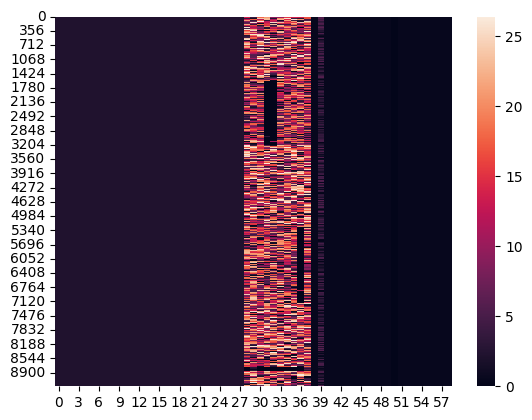

In [ ]:
# Heatmap of X (trainingsize, compounds)
sns.heatmap(pd.DataFrame(parameter.X))
plt.show()

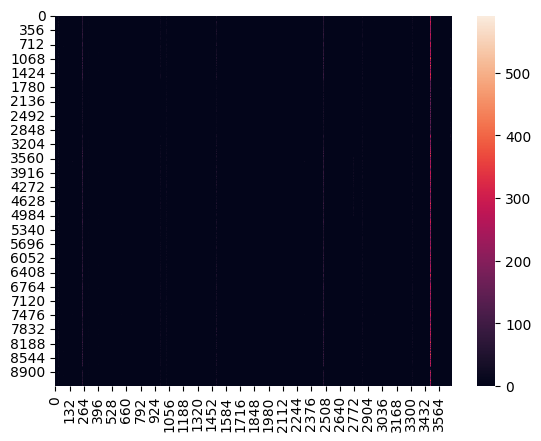

In [ ]:
# Heatmap of Y (trainingsize, flux values)
sns.heatmap(pd.DataFrame(parameter.Y))
plt.show()

## Step 4. Build Artificial Metabolic Network (AMN)

This step aims to create a hybrid AMN model for learning on the FBA-generated dataset.

This will be used as the 'Reservoir Model' in the pipeline.

5-fold cross-validation is performed on 90% of the data and an independent test-set of 10% of the data.

In [3]:
from Library.Build_Model import *
from Library.Build_Model_Wrappers import *

Using 1 GPU(s)


/nfs/homes/chinasse/amn_release/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Parameters
seed = 10
ratio_test = 0.1 # part of the training set removed for test
np.random.seed(seed=seed)  
trainname = 'AidaYing_UB' # model, bounds
  
# Create model
trainingfile = DIRECTORY+'Dataset_model/'+trainname
model = Neural_Model(trainingfile = trainingfile, 
                     objective=['BIOMASS_Ec_iML1515_core_75p37M'],  
                     model_type='AMN_QP', 
                     timestep = 4, 
                     learn_rate=0.01,
                     scaler=True,
                     n_hidden = 1, 
                     hidden_dim = 50,
                     epochs=500,
                     xfold=5,
                     batch_size=128,
                     es=True,
                     verbose=True)

# Split training and test set using ratio_test
ID = np.random.choice(model.X.shape[0], 
                      size=int(model.X.shape[0]*ratio_test), 
                      replace=False)
Xtest,  Ytest  = model.X[ID,:], model.Y[ID,:]
Xtrain, Ytrain = np.delete(model.X, ID, axis=0), np.delete(model.Y, ID, axis=0)
model.printout()

number of reactions:  3682 3682
number of metabolites:  1877
filtered measurements size:  1
training file: ./Dataset_model/AidaYing_UB
model type: AMN_QP
model scaler: 1.0
model input dim: 59
model output dim: 1
model medium bound: UB
timestep: 4
training set size (9240, 59) (9240, 1)
nbr hidden layer: 1
hidden layer size: 50
activation function: relu
gradient learn rate: 0.01
gradient decay rate: 0.9
training epochs: 500
training regression: True
training learn rate: 0.001
training dropout: 0.25
training batch size: 128
training validation iter: 0
training xfold: 5
training early stopping: True


In [5]:
# Train and evaluate with per-fold logging (~35 mins)
reservoirname = trainname + '_' + model.model_type
reservoirfile = DIRECTORY + 'Reservoir/' + reservoirname
result_dir = DIRECTORY + 'Result/' + reservoirname

start_time = time.time()
model.X, model.Y = Xtrain, Ytrain
reservoir, pred, stats, fold_records = train_evaluate_with_logging(
    model, result_dir=result_dir, prefix='cv', verbose=True)
delta_time = time.time() - start_time

# Print aggregated cross-validation results
print_stats(reservoirname, stats, delta_time)

# Save reservoir model
reservoir.save(reservoirfile)

AMN scaler 26.400000000000002
QP input shape (8316, 59) (8316, 4)

  Fold 1/5: train (6652, 59), test (1664, 59)
----------------------------------- AMN_QP
Dense layer n_hidden, hidden_dim, output_dim, activation, trainable: 1 50 3682 relu True
AMN output shapes for PoutV, SV, PinV, Vpos, V, outputs (None, 1) (None, 1) (None, 1) (None, 1) (None, 3682) (None, 7368)
nbr parameters: 190782


Training:   0%|          | 0/500 [00:00<?, ?epoch/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1770448096.124105 2299052 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Training:  14%|█▍        | 72/500 [13:50<1:21:48, 11.47s/epoch, loss=0.0085, val_loss=0.0017]

Epoch 72: early stopping


---------- 1
Loss out on V0:  0.06843996
Loss constraint on V0:  2.6823272e-05
Loss all on V0:  0.0017581793
Loss out on Vf:  0.06844456
Loss constraint on Vf:  2.6821665e-05
Loss all on Vf:  0.0017584158
Distance V0 to Vf 0.000863: 


---------- 1
Loss out on V0:  0.06709506
Loss constraint on V0:  2.6833337e-05
Loss all on V0:  0.0016867885
Loss out on Vf:  0.06709949
Loss constraint on Vf:  2.6831754e-05
Loss all on Vf:  0.001687019
Distance V0 to Vf 0.000428: 
train = 0.94 test = 0.94 loss-train = 0.000027 loss-test = 0.000027 iter=0
    R2=0.9438  Q2=0.9394  constraint_train=0.000027  constraint_test=0.000027  epochs=72

  Fold 2/5: train (6653, 59), test (1663, 59)
----------------------------------- AMN_QP
Dense layer n_hidden, hidden_dim, output_dim, activation, trainable: 1 50 3682 relu True
AMN output shapes for PoutV, SV, PinV, Vpos, V, outputs (None, 1) (None, 1) (None, 1) (None, 1) (None, 3682) (None, 7368)
nbr parameters: 190782


...

Epoch 36: early stopping


---------- 1
Loss out on V0:  0.16256393
Loss constraint on V0:  6.835539e-05
Loss all on V0:  0.009843674
Loss out on Vf:  0.16256623
Loss constraint on Vf:  6.835338e-05
Loss all on Vf:  0.009843823
Distance V0 to Vf 0.000966: 


---------- 1
Loss out on V0:  0.16407135
Loss constraint on V0:  6.8621186e-05
Loss all on V0:  0.010165558
Loss out on Vf:  0.16407359
Loss constraint on Vf:  6.8619185e-05
Loss all on Vf:  0.010165664
Distance V0 to Vf 0.000482: 
train = 0.67 test = 0.69 loss-train = 0.000068 loss-test = 0.000069 iter=0
    R2=0.6697  Q2=0.6912  constraint_train=0.000068  constraint_test=0.000069  epochs=36


---------- 1
Loss out on V0:  0.16286539
Loss constraint on V0:  6.8408546e-05
Loss all on V0:  0.009908042
Loss out on Vf:  0.16286767
Loss constraint on Vf:  6.840654e-05
Loss all on Vf:  0.0099081835
Distance V0 to Vf 0.001079: 
  Saved fold metrics to ./Result/AidaYing_UB_AMN_QP/cv_fold_metrics.csv
  Saved 5 fold predictions to ./Result/AidaYing_UB_AMN_QP/cv_fold*_predictions.csv
  Saved 5 fold histories to ./Result/AidaYing_UB_AMN_QP/cv_fold*_history.csv
  Saved collated predictions to ./Result/AidaYing_UB_AMN_QP/cv_collated_predictions.csv
--- Results: AidaYing_UB_AMN_QP (elapsed: 5830.7s) ---------------------
  R2 (train) = 0.9051 (+/- 0.1192)  |  Constraint = 0.000033 (+/- 0.000019)
  Q2 (test)  = 0.9076 (+/- 0.1101)  |  Constraint = 0.000033 (+/- 0.000019)
------------------------------------------------------------------------
./Reservoir/AidaYing_UB_AMN_QP_param.csv


/nfs/homes/chinasse/amn_release/.venv/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [6]:
# Print reservoir model
reservoir.printout()

training file: ./Dataset_model/AidaYing_UB
model type: AMN_QP
model scaler: 26.400000000000002
model input dim: 59
model output dim: 7368
model medium bound: UB
timestep: 4
training set size (8316, 59) (8316, 4)
nbr hidden layer: 1
hidden layer size: 50
activation function: relu
gradient learn rate: 0.01
gradient decay rate: 0.9
training epochs: 500
training regression: True
training learn rate: 0.001
training dropout: 0.25
training batch size: 128
training validation iter: 0
training xfold: 5
training early stopping: True


In [7]:
# Run independent test set
if len(Xtest) > 0:
    start_time = time.time()
    reservoir.X, reservoir.Y = Xtest, Ytest
    X_eval, Y_eval = model_input(reservoir, verbose=True)
    pred_test, stats_test = evaluate_model(
        reservoir.model, X_eval, Y_eval, reservoir, verbose=True)
    delta_time = time.time() - start_time
    print_stats('Independent test set', stats_test, delta_time)

    # Save test set predictions
    ensure_result_dir(result_dir)
    test_pred_path = os.path.join(result_dir, 'test_set_predictions.csv')
    np.savetxt(test_pred_path, pred_test, delimiter=',')
    print(f"  Saved test predictions to {test_pred_path}")

AMN scaler 26.400000000000002
QP input shape (924, 59) (924, 4)


---------- 1
Loss out on V0:  0.15960138
Loss constraint on V0:  6.841147e-05
Loss all on V0:  0.009450284
Loss out on Vf:  0.15960398
Loss constraint on Vf:  6.840946e-05
Loss all on Vf:  0.009450452
Distance V0 to Vf 0.000359: 
--- Results: Independent test set (elapsed: 1.6s) ----------------------
  R2 (train) = 0.6684 (+/- 0.0000)  |  Constraint = 0.000068 (+/- 0.000000)
  Q2 (test)  = 0.6684 (+/- 0.0000)  |  Constraint = 0.000068 (+/- 0.000000)
------------------------------------------------------------------------
  Saved test predictions to ./Result/AidaYing_UB_AMN_QP/test_set_predictions.csv


## 4. Get predictions using experimental data + reservoir model

Create, train and evaluate reservoir models on experimental training set 

The 5 fold cv training process is repeated with different seeds (using 3). Because the experimental dataset is smaller (900 datapoints) than the FBA-generated (9k), repeating the process with different seeds will allow to get a trustworthy performance estimate, ensuring the results aren't an artifact of one unlucky split.

In [3]:
from Library.Build_Model import *
from Library.Build_Model_Wrappers import *

Using 1 GPU(s)


/nfs/homes/chinasse/amn_release/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
seed = 10
Maxloop, Q2, PRED = 3, [], []  # 3 seeds

for Nloop in range(Maxloop):
    # Parameters
    seed = Nloop
    np.random.seed(seed=seed)  
    trainname = 'aidaying_media_growth_amns_padded'
    reservoirname = 'AidaYing_UB_AMN_QP'
  
    # Create model
    trainingfile = DIRECTORY + 'Dataset_input/' + trainname
    reservoirfile = DIRECTORY + 'Reservoir/' + reservoirname
    X, Y = read_XY(trainingfile, 59)
    model = RC_Model(reservoirfile=reservoirfile,
                     X=X, Y=Y,
                     n_hidden_prior=1,
                     hidden_dim_prior=500,
                     activation_prior='relu',
                     epochs=500,
                     train_rate=1.0e-3,
                     batch_size=128,
                     xfold=5,
                     es=True,
                     verbose=True)
    model.printout()

    # Train and evaluate with per-fold logging
    rc_result_dir = DIRECTORY + 'Result/' + reservoirname + '_' + model.model_type
    rc_prefix = f'seed{seed}_cv'
    start_time = time.time()
    reservoir, pred, stats, fold_records = train_evaluate_with_logging(
        model, result_dir=rc_result_dir, prefix=rc_prefix, verbose=True)
    delta_time = time.time() - start_time

    # Print cross-validation results
    print_stats(f'{reservoirname} (seed={seed})', stats, delta_time)
    r2 = r2_score(model.Y, pred[:, 0], multioutput='variance_weighted')
    print(f'  Seed {Nloop}: Collated Q2 = {r2:.4f}')
    Q2.append(r2)
    PRED.append(pred)

Loading model:  67%|██████▋   | 2/3 [00:17<00:08,  8.52s/it]    

number of reactions:  3682 3682
number of metabolites:  1877
filtered measurements size:  1


RC reservoir file: ./Reservoir/AidaYing_UB_AMN_QP
RC model type: RC
RC scaler: 0.0
RC model input dim: 59
RC model output dim: 1
RC model medium bound: UB
training set size (924, 59) (924, 1)
reservoir S, Pin, Pout matrices (1877, 3682) (59, 3682) (1, 3682)
RC training epochs: 500
RC training regression: True
RC training learn rate: 0.001
RC training dropout: 0.25
RC training batch size: 128
RC training validation iter: 0
RC training xfold: 5
RC training early stopping: True
--------prior network --------
training file: None
model type: ANN_Dense
model scaler: 0.0
model input dim: 12
model output dim: 12
model medium bound: 
timestep: 0
no training set provided
nbr hidden layer: 1
hidden layer size: 500
activation function: relu
--------reservoir network-----
training file: ./Dataset_model/AidaYing_UB
model type: AMN_QP
model scaler: 26.400000000000002
model input dim: 59
model output dim: 7368
model medium bound: UB
timestep: 4
training set size (9240, 59) (9240, 1)
nbr hidden layer: 

Training:   0%|          | 0/500 [00:00<?, ?epoch/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1770487761.345719 2565542 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Training:   2%|▏         | 11/500 [00:23<12:46,  1.57s/epoch, loss=0.4473, val_loss=0.4139] 

Epoch 11: early stopping


...

Training:   2%|▏         | 11/500 [00:18<12:06,  1.49s/epoch, loss=0.4522, val_loss=0.3828]

Epoch 11: early stopping


---------- 1
looping bad training iter=0 r2=-4.2225


---------- 1
train = -4.22 test = -3.26 loss-train = -1.000000 loss-test = -1.000000 iter=0
    R2=-4.2225  Q2=-3.2626  constraint_train=-1.000000  constraint_test=-1.000000  epochs=11


---------- 1
  Saved fold metrics to ./Result/AidaYing_UB_AMN_QP_RC/seed2_cv_fold_metrics.csv
  Saved 5 fold predictions to ./Result/AidaYing_UB_AMN_QP_RC/seed2_cv_fold*_predictions.csv
  Saved 5 fold histories to ./Result/AidaYing_UB_AMN_QP_RC/seed2_cv_fold*_history.csv
  Saved collated predictions to ./Result/AidaYing_UB_AMN_QP_RC/seed2_cv_collated_predictions.csv
--- Results: AidaYing_UB_AMN_QP (seed=2) (elapsed: 123.9s) -------------
  R2 (train) = -4.0231 (+/- 0.1462)  |  Constraint = -1.000000 (+/- 0.000000)
  Q2 (test)  = -4.0777 (+/- 0.5957)  |  Constraint = -1.000000 (+/- 0.000000)
------------------------------------------------------------------------
  Seed 2: Collated Q2 = -4.0196


In [6]:
# Aggregate and save results across seeds
Q2, PRED = np.asarray(Q2), np.asarray(PRED)
print(f'\nPredictions shape: {PRED.shape}')

obj = PRED[:, :, 0]
print(f'Averaged Q2 = {np.mean(Q2):.4f} (+/- {np.std(Q2):.4f})')


Predictions shape: (3, 924, 3745)
Averaged Q2 = -4.0196 (+/- 0.0000)


In [7]:
# Save to result directory
rc_result_dir = DIRECTORY + 'Result/' + reservoirname + '_' + model.model_type
ensure_result_dir(rc_result_dir)

q2_path = os.path.join(rc_result_dir, 'Q2_across_seeds.csv')
np.savetxt(q2_path, Q2, delimiter=',')
print(f'  Saved Q2 scores to {q2_path}')

pred_path = os.path.join(rc_result_dir, 'PRED_objective_across_seeds.csv')
np.savetxt(pred_path, obj, delimiter=',')
print(f'  Saved predictions to {pred_path}')

  Saved Q2 scores to ./Result/AidaYing_UB_AMN_QP_RC/Q2_across_seeds.csv
  Saved predictions to ./Result/AidaYing_UB_AMN_QP_RC/PRED_objective_across_seeds.csv


In [20]:
# Save input / output of the first prediction for Cobra runs
pred_first, obj_first = PRED[0], PRED[0][:, 0]
Loss_SV = pred_first[:, 1]
Loss_Vin = pred_first[:, 2]
Loss_Vpos = pred_first[:, 3]
print(f'\nConstraint losses (first seed):')
print(f'  Loss SV:   mean={np.mean(Loss_SV):.4f}  max={np.max(Loss_SV):.4f}')
print(f'  Loss Vin:  mean={np.mean(Loss_Vin):.4f}  max={np.max(Loss_Vin):.4f}')
print(f'  Loss Vpos: mean={np.mean(Loss_Vpos):.4f}  max={np.max(Loss_Vpos):.4f}')

V = pred_first[:, 4:4 + model.S.shape[1]]
Vin_pre_scaling = pred_first[:, 4 + model.S.shape[1]:]
Vin = model.res.scaler * Vin_pre_scaling  # rescale back for Cobra
XY = np.concatenate((Vin, Y), axis=1)
cobra_path = os.path.join(rc_result_dir, reservoirname,'_solution_for_Cobra.csv')
np.savetxt(cobra_path, XY, delimiter=',')
print(f'  Saved Cobra solution to {cobra_path}')


Constraint losses (first seed):
  Loss SV:   mean=0.0111  max=0.0199
  Loss Vin:  mean=0.0000  max=0.0000
  Loss Vpos: mean=0.0000  max=0.0000


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 0 dimension(s)

In [39]:
# Adding the column names to the Cobra solution
expfile  = DIRECTORY+'Dataset_input/aidaying_media_growth_amns_padded.csv'
exp_df = pd.read_csv(expfile)
colnames = exp_df.columns.tolist()

cobrafile = DIRECTORY+'Result/AidaYing_UB_AMN_QP_RC/AidaYing_UB_AMN_QP_RC_solution_for_Cobra.csv'
cobra_df = pd.read_csv(cobrafile)

if len(colnames) == cobra_df.shape[1]:
    cobra_df.columns = colnames
else:
    print(f'Column names do not match: {len(colnames)} != {cobra_df.shape[1]}')

cobra_df.head()

,EX_glc__D_e_i,EX_ala__L_e_i,EX_arg__L_e_i,EX_asn__L_e_i,EX_asp__L_e_i,EX_glu__L_e_i,EX_gln__L_e_i,EX_gly_e_i,EX_his__L_e_i,EX_ile__L_e_i,...,EX_malt_e_i,EX_melib_e_i,EX_tre_e_i,EX_fru_e_i,EX_gal_e_i,EX_ac_e_i,EX_lac__D_e_i,EX_succ_e_i,EX_pyr_e_i,GR_AVG
0,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.351957
1,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.212478
2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.316641
3,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.206139
4,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.209660


In [40]:
# Load original Aida & Yin dataset 
aida_path = DIRECTORY + 'Dataset_input/aidaying_media_growth_amns.csv'
aida_df = pd.read_csv(aida_path)

# Load parameter file from Faure et. al 
faure_path = DIRECTORY + 'Dataset_input/iML1515.csv'
faure_df = pd.read_csv(faure_path)

# Store column names (excluding non-compounds)
faure_cols = faure_df.columns.drop('name')
aida_cols = aida_df.columns.drop('GR_AVG')

print(f"Faure compounds: {len(faure_cols)}")
print(f"Aida & Ying compounds: {len(aida_cols)}")

# Check common compounds
common_compounds = set(faure_cols) & set(aida_cols)
print(f"Common compounds: {len(common_compounds)}")
# Check Faure only
faure_only = set(faure_cols) - set(aida_cols)
print(f"Faure only compounds: {len(faure_only)}")


Faure compounds: 38
Aida & Ying compounds: 37
Common compounds: 16
Faure only compounds: 22


In [41]:
# Removing the Faure columns
# Remove Faure compounds from Cobra solution
print(f'Before removing Faure columns: {len(cobra_df.columns)}')
cobra_df = cobra_df.drop(columns=faure_only)
print(f'After removing Faure columns: {len(cobra_df.columns)}')
print(f'Should be 38 because includes GR_AVG and 37 compounds')


Before removing Faure columns: 60
After removing Faure columns: 38
Should be 38 because includes GR_AVG and 37 compounds


In [ ]:
# Save the updated Cobra solution
new_cobrafile = DIRECTORY + 'Result/AidaYing_UB_AMN_QP_RC/AidaYing_UB_AMN_QP_RC_solution_for_Cobra_updated.csv'
cobra_df.to_csv(new_cobrafile, index=False)

## 5. Use RC predictions as input for COBRApy

The goal of this last validation is to get a better growth rate estimates, when constraining the GEM with predicted medium fluxes.

To do this, we will run COBRApy FBA on a provided training and compute R2 between the experimental and the predicted growth.

For exprimental training set medium input fluxes can be scaled by a value.


In [44]:
# Parameters
seed = 10
np.random.seed(seed=seed)  
cobraname = 'iML1515'  # name of the model 
mediumbound = 'UB' # a must, exact bounds unknown
mediumname = 'AidaYing_UB_AMN_QP_RC_solution_for_Cobra' # for running Cobra with RC predictions as inputs
method = 'EXP' # FBA, pFBA or EXP

# Get data
cobrafile =  DIRECTORY+'Dataset_input/'+cobraname
mediumfile = DIRECTORY+'Result/AidaYing_UB_AMN_QP_RC/'+mediumname
parameter = TrainingSet(cobraname=cobrafile, 
                        mediumname=mediumfile, 
                        mediumbound=mediumbound, 
                        mediumsize=37, 
                        method=method,
                        verbose=True)
scaler_list = [1] # best scaler for RC EXP input

medium: ['EX_glc__D_e_i', 'EX_ala__L_e_i', 'EX_arg__L_e_i', 'EX_asn__L_e_i', 'EX_asp__L_e_i', 'EX_glu__L_e_i', 'EX_gln__L_e_i', 'EX_gly_e_i', 'EX_his__L_e_i', 'EX_ile__L_e_i', 'EX_leu__L_e_i', 'EX_lys__L_e_i', 'EX_met__L_e_i', 'EX_phe__L_e_i', 'EX_pro__L_e_i', 'EX_ser__L_e_i', 'EX_thr__L_e_i', 'EX_trp__L_e_i', 'EX_tyr__L_e_i', 'EX_val__L_e_i', 'EX_thm_e_i', 'EX_pydxn_e_i', 'EX_cys__L_e_i', 'EX_cl_e_i', 'EX_nh4_e_i', 'EX_so4_e_i', 'EX_pi_e_i', 'EX_k_e_i', 'EX_na1_e_i', 'EX_mg2_e_i', 'EX_ca2_e_i', 'EX_fe2_e_i', 'EX_zn2_e_i', 'EX_cu2_e_i', 'EX_mobd_e_i', 'EX_cit_e_i', 'EX_tsul_e_i']
levmed: []
valmed: []
ratmed: 0
objective:  ['BIOMASS_Ec_iML1515_core_75p37M']
measurements size:  2712


In [45]:
# Regression COBRApy predicted vs. true values
L = parameter.X.shape[0]
for scaler in scaler_list:
    Y = {}
    for i in range(L):
        inf = {r.id: 0 for r in parameter.model.reactions}
        for j in range(len(parameter.medium)):
            print(j, parameter.medium[j],parameter.X[i,j], len(parameter.model.reactions))
            eps = 1.0e-4 if parameter.X[i,j] < 1.0e-4 else 0
            inf[parameter.medium[j]] = scaler * parameter.X[i,j] + eps
        out,Y[i] = run_cobra(parameter.model, parameter.objective, inf, method='pFBA', verbose=False)
        print("%d %.4f %.4f" % (i, parameter.Y[i].item(), Y[i].item()))

    Y = list(Y.values())
    r2 = r2_score(parameter.Y[0:L], Y[0:L], multioutput='variance_weighted')
    print('scaler %.2f R2 %.4f ' % (scaler, r2))

0 EX_glc__D_e_i 2.200000065565109 2712
1 EX_ala__L_e_i 2.200000065565109 2712
2 EX_arg__L_e_i 2.200000065565109 2712
3 EX_asn__L_e_i 2.200000065565109 2712
4 EX_asp__L_e_i 2.200000065565109 2712
5 EX_glu__L_e_i 2.200000065565109 2712
6 EX_gln__L_e_i 2.200000065565109 2712
7 EX_gly_e_i 2.200000065565109 2712
8 EX_his__L_e_i 2.200000065565109 2712
9 EX_ile__L_e_i 2.200000065565109 2712
10 EX_leu__L_e_i 2.200000065565109 2712
11 EX_lys__L_e_i 2.200000065565109 2712
12 EX_met__L_e_i 2.200000065565109 2712
13 EX_phe__L_e_i 2.200000065565109 2712
14 EX_pro__L_e_i 2.200000065565109 2712
15 EX_ser__L_e_i 2.200000065565109 2712
16 EX_thr__L_e_i 2.200000065565109 2712
17 EX_trp__L_e_i 2.200000065565109 2712
18 EX_tyr__L_e_i 2.200000065565109 2712
19 EX_val__L_e_i 2.200000065565109 2712
20 EX_thm_e_i 2.200000065565109 2712
21 EX_pydxn_e_i 2.200000065565109 2712
22 EX_cys__L_e_i 2.200000065565109 2712
23 EX_cl_e_i 2.200000065565109 2712
24 EX_nh4_e_i 2.200000065565109 2712
25 EX_so4_e_i 2.20000006

Infeasible: None (infeasible).